In [15]:
import pandas as pd
import seaborn as sns
import re
#import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import sys

from pathlib import Path
#from pymc.distributions.transforms import Interval
from collections import defaultdict, Counter
from pandas.api.types import is_string_dtype
from scipy.spatial.distance import squareform, pdist
from statsmodels.stats.outliers_influence import variance_inflation_factor

from utils.plotUtils import (returnOrderJacksonTali, returnTropicalViruses, returnViruses, returnVirusesAll,
                             returnVirusesLabelDict, returnColorDict, annotateWithLetter,
                             forestPlotMultipleModels, ridgeForestPlot)
from utils.dataUtils import loadData, createColonysizeDf, createSpeciesDf, lognormalMuFromMean, preprocessDfModelSimple, preprocessDfModelB
from utils.regression import RANDOM_SEED, fitSimple, fitMultilevelB, variableTransformationModelB, pm

In [16]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [17]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
pd.set_option('display.max_rows', 500)

# Utils

In [19]:
def exponentiateIData(iDataLogOdds):
    # Exponentiate the posterior draws to go from log odds ratios to odds ratios.
    # Note: we're going from log odds to odds for the intercept according to 
    # https://stats.oarc.ucla.edu/other/mult-pkg/faq/general/faq-how-do-i-interpret-odds-ratios-in-logistic-regression/
    return iDataLogOdds.map(lambda posterior: np.exp(posterior), groups="posterior")

In [20]:
def logistic(x):
    return 1/(1+np.exp(-x))

In [21]:
def addJittering(df, cols, sd=0.075):
    newDf = {}
    for col in cols:
        if is_string_dtype(df[col]):
            maskNa = df[col].isna()
            numCol = pd.Categorical(df[col]).codes
            stdev = sd * (numCol.max() - numCol.min())
            jittered = pd.Series(numCol + np.random.randn(len(df[col])) * stdev)
            jittered[maskNa] = pd.NA
            newDf[col] = jittered
        else:
            stdev = sd * (df[col].max() - df[col].min())
            jittered = df[col] + np.random.randn(len(df[col])) * stdev
            newDf[col] = jittered
    return pd.DataFrame(newDf)

In [22]:
def standardize(pdSeries):
    return (pdSeries - pdSeries.mean()) / pdSeries.std()

In [23]:
def randJitter(arr, std=0.01):
    stdev = std * (max(arr) - min(arr))
    return arr + np.random.randn(len(arr)) * stdev

In [24]:
figureDir = Path("..", "figures")
resultsDir = Path("..", "results")

# Load and preprocess data

In [25]:
dfOrig, df, dfTropical = loadData()

In [26]:
orderJacksonTali = returnOrderJacksonTali
colorDict = returnColorDict(df)
tropicalViruses = returnTropicalViruses()
virusesLabels = returnVirusesLabelDict()
allViruses = returnViruses()
regionDict = {"ghana": "Ghana", "gabon_congo": "Congo, Gabon", "panama": "Panama"}
regionYearDict = {"gabon_congo2003": "Congo, Gabon 2003", "gabon_congo2005": "Congo, Gabon 2005", "gabon_congo2006": "Congo, Gabon 2006",
                  "gabon_congo2008": "Congo, Gabon 2008", "gabon_congo2009": "Congo, Gabon 2009", "ghana2009": "Ghana 2009", 
                  "ghana2010": "Ghana 2010", "panama2011": "Panama 2011"}
virusFamilies = [["denv2", "yfv", "wnv"], ["measles", "mumps", "piv1", "piv2"], ["chikv", "veev"], 
                 ["sars-cov", "hcov-229e"], ["rvfv"], ["rsv"]]

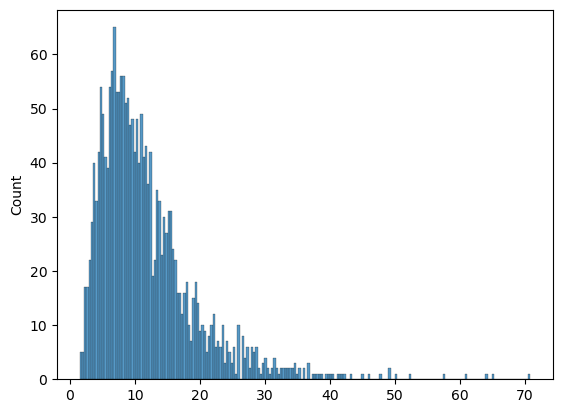

In [27]:
# Manual exploration of different sigma values to visualize lifespan distribution.
sigma = 0.6
meanLifespan = 12
maxLifespan = 45
sample = np.random.lognormal(lognormalMuFromMean(meanLifespan, sigma), sigma, size=2000)
#sampleTruncated = [elem for elem in sample if elem <= maxLifespan]
ax = sns.histplot(sample, bins=200)

In [28]:
print(f"Lower quartile: {np.quantile(sample, 0.25)}")
print(f"Upper quartile: {np.quantile(sample, 0.75)}")
print(f"5% percentile: {np.quantile(sample, 0.05)}")
print(f"95% percentile: {np.quantile(sample, 0.95)}")

Lower quartile: 6.656228896369779
Upper quartile: 14.735393792983285
5% percentile: 3.6315734116807743
95% percentile: 26.71028535405047


# Plotting

## Mean seropositivities for each virus and for each combination of bat species, sampling site, and sampling year

In [30]:
dfPlot = df.copy()
dfPlot["speciesSiteYear"] = dfPlot.apply(lambda row: row["genus"].capitalize() + " " + row["species"].capitalize() + ", " + row["site"].capitalize() + ", " + str(row["year"]), axis=1)
dfPlot[f"nSample"] = dfPlot.groupby(["species", "year", "site"]).transform("size")

dfPlotRobust = dfPlot.groupby("speciesSiteYear").filter(lambda group: len(group) >= 5)
dfPlotCurr = dfPlotRobust

for virus in allViruses:
    _, ax = plt.subplots(1, 1, figsize=(10, 5))

    dfPlotCurr[f"meanSeroPositivity{virus.capitalize()}"] = dfPlotCurr.groupby(["species", "year", "site"])[virus].transform("mean")
    
    dfPlotSorted = dfPlotCurr.sort_values(by=["species", "family", "year", "region", "country", "site"], ascending=True)
    speciesCounts = []
    #countryCounts = Counter()
    for species, group in dfPlotSorted.groupby("species"):
        nSpecies = group.speciesSiteYear.nunique()
        speciesCounts.append(nSpecies)
        #countryCounts[countrySite[0]] += nS
    
    sns.scatterplot(data=dfPlotSorted, x="speciesSiteYear", y=f"meanSeroPositivity{virus.capitalize()}", 
                    hue="site", size=f"nSample", ax=ax)
    ax.set_ylabel(f"Mean sero-positivity {virusesLabels[virus]}", fontsize=14)
    ax.set_xlabel("")

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
    ax.get_legend().remove()
    
    lastXPos = -0.5
    for count in speciesCounts:#[::-1][:-1]:
        currentXPos = lastXPos + count
        plt.axvline(currentXPos, color="gray", linewidth=0.5)
        lastXPos = currentXPos

    plt.axvline(currentXPos, color="white", linewidth=0.55) # Remove last line
    outputFile = figureDir / f"seroposrateBySpecies{virus.capitalize()}.png"
    # plt.savefig(outputFile, dpi=300, bbox_inches="tight")

In [20]:
dfPlot = df.copy()
dfPlot["siteYearSpecies"] = dfPlot.apply(lambda row: row["site"].capitalize() + ", " + str(row["year"]) + ", " + row["genus"].capitalize() + " " + row["species"].capitalize(), axis=1)

dfPlotRobust = dfPlot.groupby("siteYearSpecies").filter(lambda group: len(group) >= 5)
dfPlotCurr = dfPlotRobust

for virus in allViruses:
    _, ax = plt.subplots(1, 1, figsize=(10, 5))

    dfPlotCurr[f"meanSeroPositivity{virus.capitalize()}"] = dfPlotCurr.groupby(["year", "site", "species"])[virus].transform("mean")
    dfPlotCurr[f"nSample{virus.capitalize()}"] = dfPlotCurr.groupby(["year", "site", "species"]).transform("size")
    
    dfPlotSorted = dfPlotCurr.sort_values(by=["region", "country", "site", "year", "species"], ascending=True)
    siteCounts = []
    countryCounts = Counter()
    for regionCountrySite, group in dfPlotSorted.groupby(["region", "country", "site"]):
        for countrySite, group2 in group.groupby(["country", "site"]):
            nSites = group.siteYearSpecies.nunique()
            siteCounts.append(nSites)
            countryCounts[countrySite[0]] += nSites
    
    sns.scatterplot(data=dfPlotSorted, x="siteYearSpecies", y=f"meanSeroPositivity{virus.capitalize()}", 
                    hue="species", size=f"nSample{virus.capitalize()}", ax=ax)
    ax.set_ylabel(f"Mean sero-positivity {virusesLabels[virus]}", fontsize=14)
    ax.set_xlabel("")

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
    ax.get_legend().remove()
    
    lastXPos = -0.5
    for count in siteCounts:#[::-1][:-1]:
        currentXPos = lastXPos + count
        plt.axvline(currentXPos, color="gray", linewidth=0.5)
        lastXPos = currentXPos
    lastXPos = -0.5
    for count in list(countryCounts.values()):#[::-1][:-1]:
        currentXPos = lastXPos + count
        plt.axvline(currentXPos, color="black", linewidth=0.75)
        lastXPos = currentXPos

    plt.axvline(currentXPos, color="white", linewidth=0.55) # Remove last line
    outputFile = figureDir / f"seroposrateBySite{virus.capitalize()}.png"
    plt.savefig(outputFile, dpi=300, bbox_inches="tight")

## Heatmap

In [31]:
# Computation following: https://www.learndatasci.com/glossary/jaccard-similarity/
def jaccardSim(row1, row2):
    nBothOne = ((row1 == 1) & (row2 == 1)).sum()
    numerator = nBothOne
    denominator = nBothOne + (row1 != row2).sum()
    if denominator:
        return numerator / denominator
    else:
        return 0 
    

def createAnnotation(df, viruses):
    annot = []
    for i, virus1 in enumerate(viruses):
        for j, virus2 in enumerate(viruses):
            annot.append(((df[virus1] == 1) & (df[virus2] == 1)).sum())
    nViruses = len(viruses)
    annot = np.array(annot).reshape((nViruses, nViruses))   
    return annot

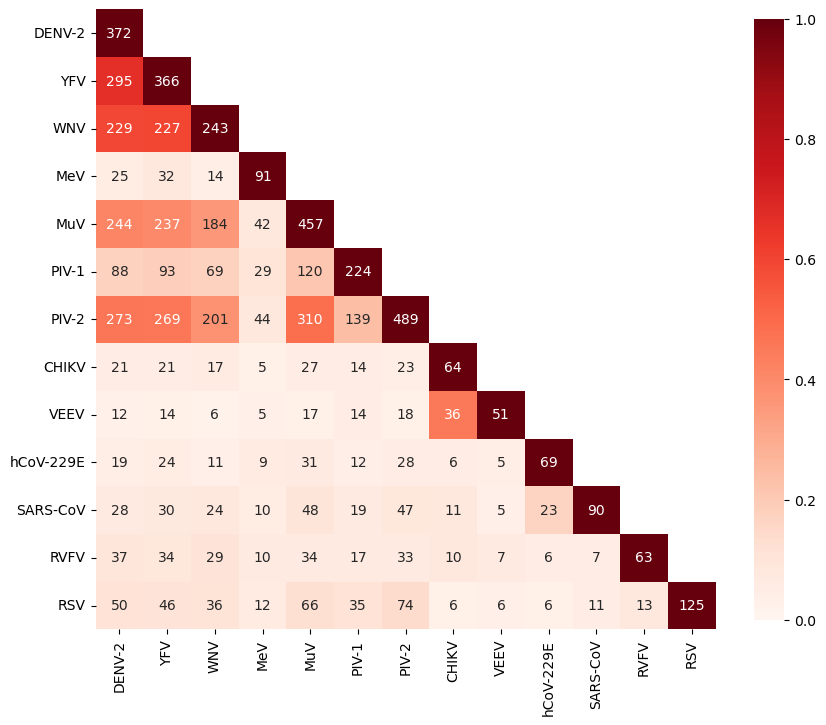

In [32]:
_, ax = plt.subplots(1, 1, figsize=(10, 10))

tropical = True

if tropical:
    dfCorr = dfTropical
    allVirusesCurrent = allViruses
    tropical_suffix = "_tropical_bats"
else:
    _, dfAll, _ = loadData(animal="all")
    dfCorr = dfAll
    allVirusesCurrent = returnVirusesAll()
    tropical_suffix = ""

dfCorr = dfCorr[list(allVirusesCurrent)].dropna()
jacSim = squareform(pdist(dfCorr.T, lambda row1, row2: jaccardSim(row1, row2)))
jacSim = pd.DataFrame(jacSim, index=dfCorr.columns, columns=dfCorr.columns)
annot = createAnnotation(dfCorr, viruses=allVirusesCurrent)

# Identical samples are perfectly correlated
for idx in jacSim.index:
    for col in jacSim.columns:
        if idx == col:
            jacSim.loc[idx, col] = 1

nViruses = len(allVirusesCurrent)
mask = []
for i in range(nViruses):
    for j in range(nViruses):
        mask.append(i < j)  
mask = np.array(mask).reshape((nViruses, nViruses))

sns.heatmap(
    jacSim,
    square=True,
    cmap="Reds",
    annot=annot,
    annot_kws={"fontsize": 10},
    fmt="d",
    vmin=0,
    vmax=1,
    mask=mask,
    #cbar=cbar,
    cbar_kws={"shrink": 0.78},
    ax=ax#[i]
)

currentXLabels = ax.get_xticklabels()
newXLabels = [virusesLabels[label.get_text()] for label in currentXLabels]
currentYLabels = ax.get_yticklabels()
newYLabels = [virusesLabels[label.get_text()] for label in currentYLabels]

ax.set_xticklabels(newXLabels)
ax.set_yticklabels(newYLabels);

plt.savefig(figureDir / f"heatmap{tropical_suffix}.png", dpi=600, bbox_inches="tight")


# Regression

## Simple model (Model A)

In [33]:
featuresSimple = ["yangochiroptera", "migration", "insectivorous", "cave", "logColonysizeMean", "adult", "male"]
dfSimple = preprocessDfModelSimple(dfTropical)

In [34]:
simpleNormalModels = {}
simpleNormalPriorPred = {}
simpleNormalResults = {}

In [35]:
simpleStudenttModels = {}
simpleStudenttPriorPred = {}
simpleStudenttResults = {}

### Variance inflation factor

In [8]:
X = dfSimple[featuresSimple]
vifData = pd.DataFrame()
vifData["Variable"] = X.columns
vifData["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

In [9]:
vifData

,Variable,VIF
0,yangochiroptera,1.300386
1,migration,4.712626
2,insectivorous,2.684995
3,cave,3.184489
4,logColonysizeMean,2.326936
5,adult,3.892601
6,male,2.257130


### Prior predictive check

In [37]:
print(f"Number of datapoints: {len(dfSimple)}")

studentt = False
simpleModels = simpleStudenttModels if studentt else simpleNormalModels
simplePriorPred = simpleStudenttPriorPred if studentt else simpleNormalPriorPred

for virus in allViruses:
    m, iData = fitSimple(virus, dfSimple, prior_predictive=True, studentt=studentt)
    simpleModels[virus] = m
    simplePriorPred[virus] = iData

Text(0.5, 1.0, 'denv2')

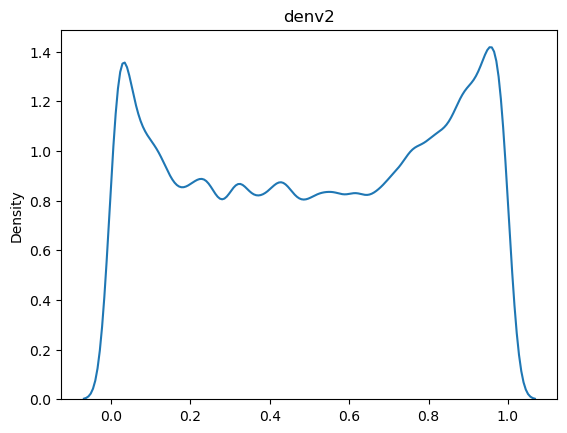

In [46]:
_, ax = plt.subplots(1, 1)
virus = "denv2" # We have the same density for all viruses.

iData = simplePriorPred[virus]
p_bar = iData.prior.p_bar.values.flatten()

sns.kdeplot(p_bar, ax=ax)
ax.set_title(virus)

### Fitting

In [39]:
studentt = False
simpleModels = simpleStudenttModels if studentt else simpleNormalModels
simpleResults = simpleStudenttResults if studentt else simpleNormalResults

for virus in allViruses:
    if virus in simpleResults: continue
    print(virus)
    m, iData = fitSimple(virus, dfSimple, target_accept=0.9, studentt=studentt)
    simpleModels[virus] = m
    simpleResults[virus] = iData

In [22]:
forestPlotDir = resultsDir / "modelA" / "forestPlots"
if not forestPlotDir.exists(): forestPlotDir.mkdir(parents=True, exist_ok=True)

### Posterior checks

#### Summarize

In [40]:
var_dict = {"intercept": "Intercept",
            "yangochiroptera": "Yangochiroptera",
            "migration": "Migratory",
            "insectivorous": "Insectivorous",
            "cave": "Cave-dwelling",
            "colonysize_5units": "Log colony size (5 log units)",
            "adult": "Adult",
            "male": "Male"}

In [41]:
# Save summary tables.
tablesDir = resultsDir / "tables"
if not tablesDir.exists(): tablesDir.mkdir(parents=True, exist_ok=True)

summaryAllVirusesA = {}


for virus in allViruses:
    summaryDfA = az.summary(simpleResults[virus], var_names=list(var_dict.keys()), round_to=2)
    summaryAllVirusesA[f"mean ({virusesLabels[virus]})"] = list(summaryDfA["mean"])
    summaryAllVirusesA[f"sd ({virusesLabels[virus]})"] = list(summaryDfA["sd"])
    summaryAllVirusesA[f"hdi_3% ({virusesLabels[virus]})"] = list(summaryDfA["hdi_3%"])
    summaryAllVirusesA[f"hdi_97% ({virusesLabels[virus]})"] = list(summaryDfA["hdi_97%"])
    summaryAllVirusesA[f"r_hat ({virusesLabels[virus]})"] = list(summaryDfA["r_hat"])


    
summaryAllVirusesA["parameter"] = var_dict.values()
summaryAllVirusesDfA = pd.DataFrame(summaryAllVirusesA).set_index("parameter")
summaryAllVirusesDfA.to_csv(tablesDir / "modelA.tsv", sep="\t", float_format="%.2f")

In [42]:
summaryAllVirusesDfA

,mean (DENV-2),sd (DENV-2),hdi_3% (DENV-2),hdi_97% (DENV-2),r_hat (DENV-2),mean (YFV),sd (YFV),hdi_3% (YFV),hdi_97% (YFV),r_hat (YFV),...,mean (RVFV),sd (RVFV),hdi_3% (RVFV),hdi_97% (RVFV),r_hat (RVFV),mean (RSV),sd (RSV),hdi_3% (RSV),hdi_97% (RSV),r_hat (RSV)
parameter,,,,,,,,,,,,,,,,,,,,,
Intercept,-3.14,0.38,-3.86,-2.42,1.0,-2.84,0.37,-3.53,-2.14,1.0,...,-2.72,0.45,-3.55,-1.86,1.0,-2.68,0.40,-3.46,-1.94,1.0
Yangochiroptera,-0.73,0.33,-1.35,-0.11,1.0,-0.75,0.33,-1.37,-0.15,1.0,...,-0.52,0.37,-1.24,0.17,1.0,-0.10,0.33,-0.70,0.52,1.0
Migratory,0.44,0.32,-0.16,1.04,1.0,0.42,0.31,-0.18,1.00,1.0,...,-0.01,0.35,-0.67,0.65,1.0,0.69,0.34,0.07,1.33,1.0
Insectivorous,-1.14,0.24,-1.59,-0.68,1.0,-1.17,0.24,-1.63,-0.71,1.0,...,-0.32,0.32,-0.95,0.27,1.0,-0.84,0.28,-1.36,-0.31,1.0
Cave-dwelling,0.79,0.20,0.42,1.17,1.0,0.53,0.19,0.17,0.90,1.0,...,-0.05,0.27,-0.56,0.45,1.0,0.25,0.22,-0.16,0.66,1.0
Log colony size (5 log units),1.55,0.11,1.34,1.75,1.0,1.46,0.10,1.27,1.66,1.0,...,-0.12,0.16,-0.43,0.18,1.0,-0.33,0.13,-0.58,-0.08,1.0
Adult,0.41,0.19,0.06,0.76,1.0,0.35,0.18,-0.00,0.69,1.0,...,0.17,0.27,-0.34,0.68,1.0,0.39,0.23,-0.03,0.82,1.0
Male,0.11,0.16,-0.19,0.43,1.0,0.09,0.16,-0.21,0.38,1.0,...,0.10,0.24,-0.34,0.54,1.0,0.15,0.18,-0.20,0.49,1.0


#### Plotting

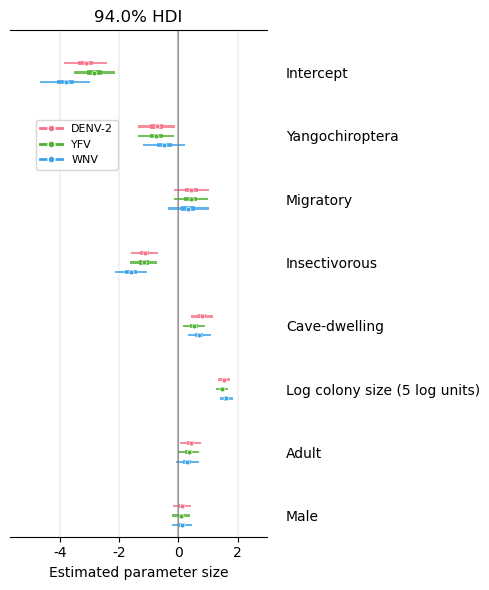

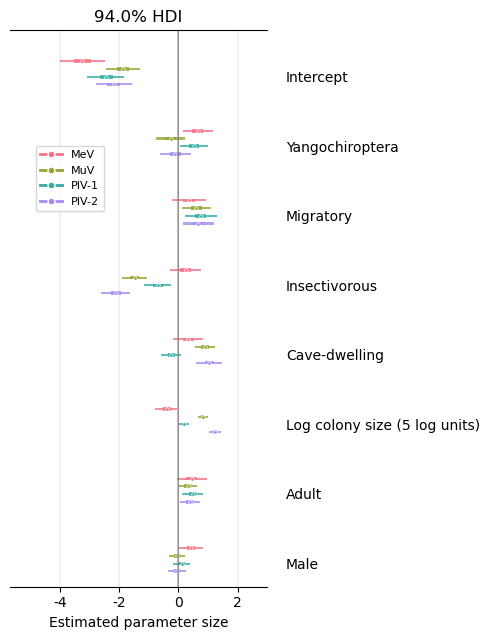

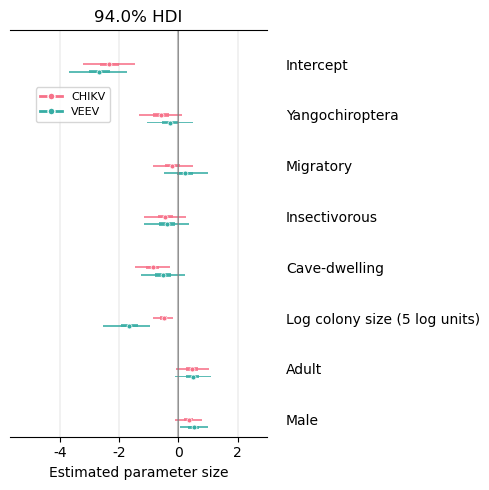

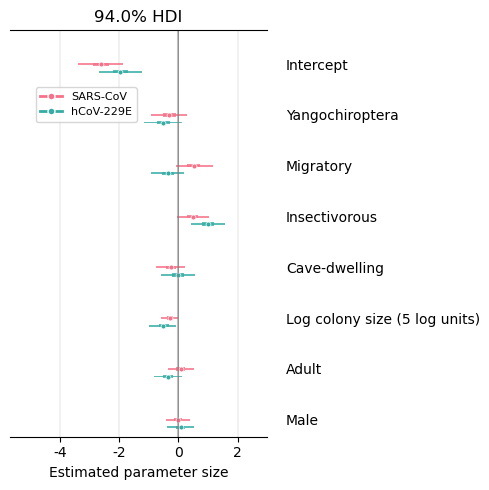

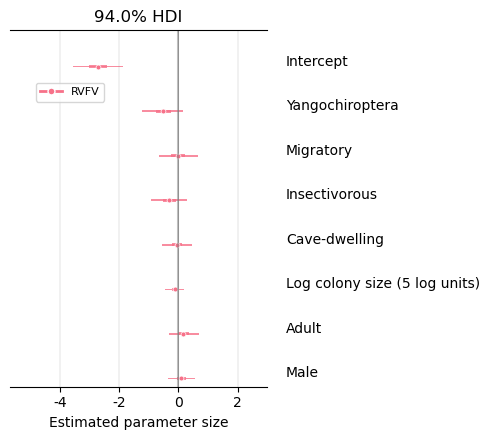

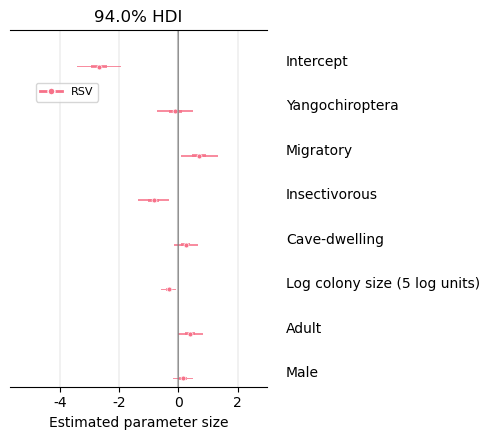

In [43]:
iDataLists = []
for virusFamily in virusFamilies:
    virusFamilyList = []
    for virus in virusFamily:
        virusFamilyList.append(simpleResults[virus])
    iDataLists.append(virusFamilyList)
    
virusCount = 0
for virusFamily, iDataList in zip(virusFamilies, iDataLists):
    
    if "mumps" in virusFamily:
        markersize=2.5
        linewidth50=0.07
        linewidth94=0.04
        yDistance=0.15
    else:
        markersize=3.5
        linewidth50=0.09
        linewidth94=0.05
        yDistance=0.2
        
    if len(virusFamily) == 4:
        figsize = (5, 6.5)
        legendLoc=(0.1, 0.675)
    elif len(virusFamily) == 3:
        figsize=(5, 6)
        legendLoc=(0.1, 0.725)
    elif len(virusFamily) == 2:
        figsize = (5, 5)
        legendLoc=(0.1, 0.775)
    elif len(virusFamily) == 1:
        figsize = (5, 4.5)
        legendLoc=(0.1, 0.8)
    
    _, ax = plt.subplots(1, 1, figsize=figsize)
    labels = [virusesLabels[virus] for virus in virusFamily]
    forestPlotMultipleModels(iDataList, varNames=var_dict.keys(),
                             legendLabels=labels, 
                             yTickLabels=list(var_dict.values())[::-1], xlim=(-5.7, 3),
                             markersize=markersize,
                             linewidth50=linewidth50,
                             linewidth94=linewidth94,
                             yDistance=yDistance,
                             ax=ax, legendLoc=legendLoc)
    
    ax.vlines(0, ymin=-20, ymax=30, color="gray", alpha=0.5)
    virusCount += len(virusFamily)
    plt.savefig(forestPlotDir / f"{'-'.join(virus for virus in virusFamily)}.png", dpi=600, bbox_inches="tight")

### Posterior predictive checks

In [45]:
_, ax = plt.subplots(4, 2, figsize=(10, 20))
ax = ax.flatten()

for a, virus in zip(ax, tropicalViruses):
    dfSimpleVirus = dfSimple.dropna(subset=[virus])
    idxSortedColonysize = np.argsort(dfSimpleVirus.logColonysizeMean).values
    sns.scatterplot(x=randJitter(dfSimpleVirus.logColonysizeMean.iloc[idxSortedColonysize], std=0.02), y=randJitter(dfSimpleVirus[virus].iloc[idxSortedColonysize]),
                    alpha=0.15, ax=a)
    pbars = az.extract(simpleResults[virus].posterior.p_bar).mean(dim="sample").p_bar.values.flatten()[idxSortedColonysize]
    sns.scatterplot(x=randJitter(dfSimpleVirus.logColonysizeMean.iloc[idxSortedColonysize]), y=randJitter(pbars), ax=a, alpha=0.15)
    a.set_title(virus)
plt.tight_layout()

## Multilevel model (Model B)

In [46]:
# with bat family as random effects, including colony size (with uncertainty) and lifespan (with uncertainty), including adult, 
# using truncated prior for colonysize, adjustment for each combination of sample group

families = ["emballonuridae", "hipposideridae", "miniopteridae", "phyllostomidae", "pteropodidae", "rhinolophidae"]
regions = ["gabon_congo", "ghana", "panama"]
regionYearCombinations = ["gabon_congo2003", "gabon_congo2005",  "gabon_congo2006", "gabon_congo2008", "gabon_congo2009", 
                          "ghana2009", "ghana2010", "panama2011"]
featuresMultilevelB = ["migration", "insectivorous", "cave", "logColonysizeMean", "male", "adult", "lifespanMean", "family", "region"]

dfMultilevelB = dfTropical.copy()
dfMultilevelB = preprocessDfModelB(dfMultilevelB)

#### Variance inflaction factor

In [48]:
X = dfMultilevelB[featuresMultilevelB]
# One-hot encode categorical variables
X = pd.get_dummies(X, columns=["family", "region"], drop_first=True, dtype=int)

# Turn categorical variables family and region into one-hot encoded variables
vifData = pd.DataFrame()
vifData["Variable"] = X.columns
vifData["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

In [16]:
vifData

### Prior predictive checks

In [50]:
multilevelNormalModelsB = {}
multilevelNormalResultsB = {}
multilevelNormalPriorPredB = {}

multilevelNormalModelsBWoAdult = {}
multilevelNormalResultsBWoAdult = {}
multilevelNormalPriorPredBWoAdult = {}

In [51]:
multilevelStudenttModelsB = {}
multilevelStudenttResultsB = {}
multilevelStudenttPriorPredB = {}

multilevelStudenttModelsBWoAdult = {}
multilevelStudenttResultsBWoAdult = {}
multilevelStudenttPriorPredBWoAdult = {}

In [53]:
print(f"Number of datapoints: {len(dfMultilevelB)}")

studentt = False
multilevelModels = multilevelStudenttModelsB if studentt else multilevelNormalModelsB
multilevelPriorPred = multilevelStudenttPriorPredB if studentt else multilevelNormalPriorPredB

for virus in allViruses:
    m, iData, dfColonysize = fitMultilevelB(virus, dfMultilevelB, target_accept=0.9, 
                                            prior_predictive=True, studentt=studentt)
    multilevelModels[virus] = m
    multilevelPriorPred[virus] = iData

In [ ]:
_, ax = plt.subplots(1, 1)
virus = "denv2" # We have the same density for all viruses.


iData = multilevelPriorPred[virus]
p_bar = iData.prior.p_bar.values.flatten()

sns.kdeplot(p_bar, ax=ax)
ax.set_title(virus)

### Fitting

#### Including adult variable (to estimate adult effect as a proxy of age).

In [54]:
studenttMultilevelB = False
multilevelModelsB = multilevelStudenttModelsB if studenttMultilevelB else multilevelNormalModelsB
multilevelResultsB = multilevelStudenttResultsB if studenttMultilevelB else multilevelNormalResultsB

for virus in allViruses:
    print(virus)
    # Models for these viruses showed divergences with lower target_accept values.
    target_accept = 0.98 if virus in ("rvfv", "sars-cov", "chikv", "veev") else 0.95

    m, iData, _ = fitMultilevelB(virus, dfMultilevelB, target_accept=target_accept, studentt=studenttMultilevelB)
    multilevelModelsB[virus] = m
    multilevelResultsB[virus] = iData

denv2
yfv
wnv
measles
mumps
piv1
piv2
chikv
veev
hcov-229e
sars-cov
rvfv
rsv


#### Excluding adult variable.

In [56]:
studenttMultilevelB = False
multilevelModelsBWoAdult = multilevelStudenttModelsBWoAdult if studenttMultilevelB else multilevelNormalModelsBWoAdult
multilevelResultsBWoAdult = multilevelStudenttResultsBWoAdult if studenttMultilevelB else multilevelNormalResultsBWoAdult

for virus in allViruses:
    if virus in multilevelResultsBWoAdult: continue
    print(virus)
    if virus in ("rvfv", "sars-cov", "chikv", "veev"):
        target_accept = 0.98
    else:
        target_accept = 0.95
    m, iData, _ = fitMultilevelB(virus, dfMultilevelB, target_accept=target_accept, studentt=studenttMultilevelB, 
                                 includeAdult=False)
    multilevelModelsBWoAdult[virus] = m
    multilevelResultsBWoAdult[virus] = iData

### Posterior checks

In [57]:
includeAdult = True
if includeAdult:
    adultSuffix = ""
    resultsB = multilevelResultsB
    var_names = ["intercept", "migration", "insectivorous", "cave", "colonysize_5units", 
                 "adult", "lifespan_5years", "male", "family", "region_year_2"]
    plot_labels = ["Intercept", "Migratory", "Insectivorous", "Cave-dwelling", 
                   "Log colony size (5 log units)", "Adult", "Lifespan (5 years)", "Male"] + [family.capitalize() for family in families] + \
                  [regionYearDict[region_year] for region_year in regionYearCombinations]
else:
    adultSuffix = "WoAdult"
    resultsB = multilevelResultsBWoAdult
    var_names = ["intercept", "lifespan_5years", "migration", "insectivorous", "cave", "colonysize_5units", 
                 "male", "family", "region_year_2"]
    plot_labels = ["Intercept", "Lifespan (5 years)", "Migratory", "Insectivorous", "Cave-dwelling", 
                   "Log colony size (5 log units)", "Male"] + [family.capitalize() for family in families] + \
                  [regionYearDict[region] for regionYear in regionYearDictCombinations]

In [58]:
# Check for divergences
for virus in allViruses:
    print(virus)
    print(resultsB[virus].sample_stats.diverging.sum())

denv2
<xarray.DataArray 'diverging' ()> Size: 8B
array(0)
yfv
<xarray.DataArray 'diverging' ()> Size: 8B
array(0)
wnv
<xarray.DataArray 'diverging' ()> Size: 8B
array(0)
measles
<xarray.DataArray 'diverging' ()> Size: 8B
array(0)
mumps
<xarray.DataArray 'diverging' ()> Size: 8B
array(0)
piv1
<xarray.DataArray 'diverging' ()> Size: 8B
array(0)
piv2
<xarray.DataArray 'diverging' ()> Size: 8B
array(0)
chikv
<xarray.DataArray 'diverging' ()> Size: 8B
array(0)
veev
<xarray.DataArray 'diverging' ()> Size: 8B
array(0)
hcov-229e
<xarray.DataArray 'diverging' ()> Size: 8B
array(0)
sars-cov
<xarray.DataArray 'diverging' ()> Size: 8B
array(0)
rvfv
<xarray.DataArray 'diverging' ()> Size: 8B
array(0)
rsv
<xarray.DataArray 'diverging' ()> Size: 8B
array(0)


#### Summarize

In [59]:
forestPlotDir = resultsDir / "modelB" / "forestPlots"
if not forestPlotDir.exists(): forestPlotDir.mkdir(parents=True, exist_ok=True)

In [60]:
familyLabels = {f"family[{i}]": family.capitalize() for i, family in enumerate(families)}
regionYearLabels = {f"region_year[{i}]": regionYear for i, regionYear in enumerate(regionYearDict.values())}
var_dict_tables = {"intercept": "Intercept",
                   "migration": "Migratory",
                   "insectivorous": "Insectivorous",
                   "cave": "Cave-dwelling",
                   "colonysize_5units": "Log colony size (5 log units)",
                   "adult": "Adult",
                   "lifespan_5years": "Lifespan (5 years)",
                   "male": "Male",}

var_dict_tables.update(familyLabels)
var_dict_tables.update(regionYearLabels)

# Save summary tables.
tablesDir = resultsDir / "tables"
if not tablesDir.exists(): tablesDir.mkdir(parents=True, exist_ok=True)

summaryAllVirusesB = {}

for virus in allViruses:
    # !! TODO: ignore viruses with high rhats below
    if virus in (""): continue
    summaryDfB = az.summary(resultsB[virus], var_names=list(var_names), round_to=2)
    summaryAllVirusesB[f"mean ({virusesLabels[virus]})"] = list(summaryDfB["mean"])
    summaryAllVirusesB[f"sd ({virusesLabels[virus]})"] = list(summaryDfB["sd"])
    summaryAllVirusesB[f"hdi_3% ({virusesLabels[virus]})"] = list(summaryDfB["hdi_3%"])
    summaryAllVirusesB[f"hdi_97% ({virusesLabels[virus]})"] = list(summaryDfB["hdi_97%"])
    summaryAllVirusesB[f"r_hat ({virusesLabels[virus]})"] = list(summaryDfB["r_hat"])
    
summaryAllVirusesB["parameter"] = list(var_dict_tables.values())
summaryAllVirusesDfB = pd.DataFrame(summaryAllVirusesB).set_index("parameter")#.drop("index", axis=1)
summaryAllVirusesDfB.to_csv(tablesDir / "modelB.tsv", sep="\t", float_format="%.2f")

#### Plotting

In [ ]:
# includeAdult = True
# adultSuffix = "WAdult" if includeAdult else ""
# includeRegion = True
# regionSuffix = "WRegion" if includeRegion else ""
# resultsSuffixMultilevelB = "StudenttPriors" if studenttMultilevelB else "NormalPriors"
# resultsDir = Path("..", "results", f"multilevelB{resultsSuffixMultilevelB}{adultSuffix}{regionSuffix}")

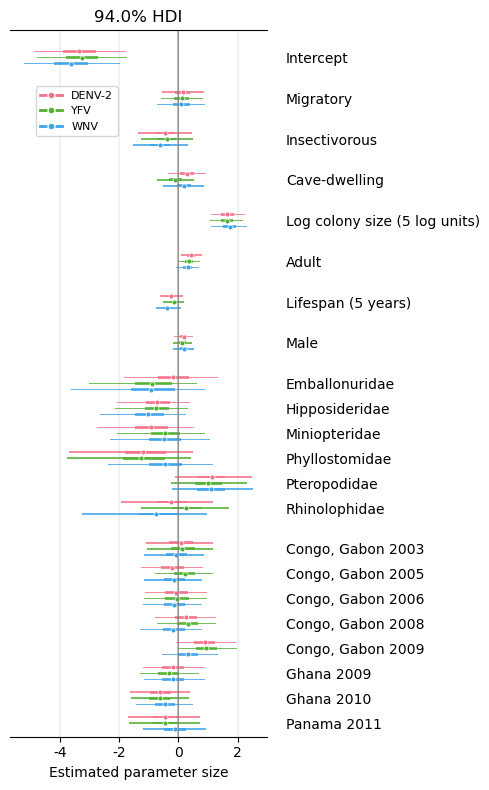

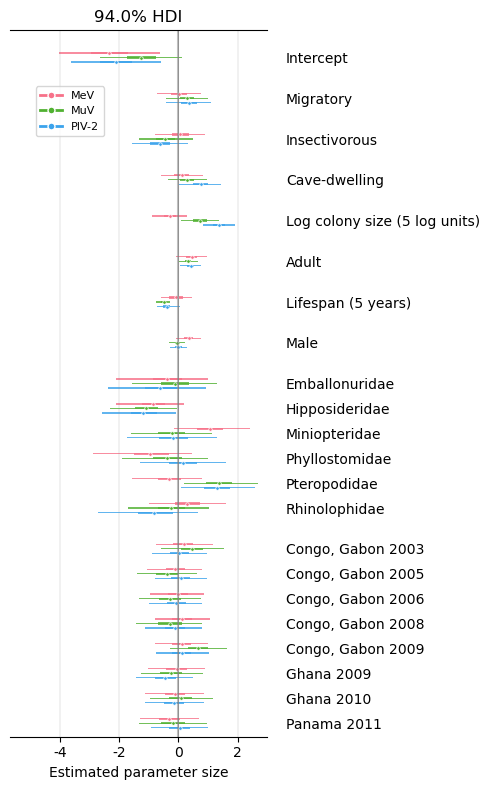

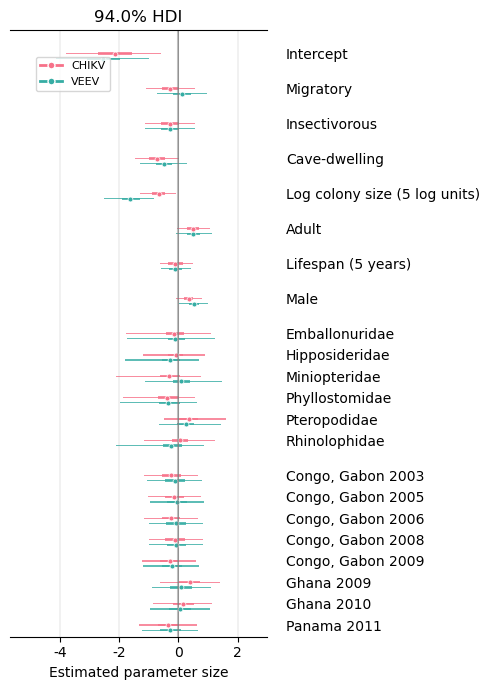

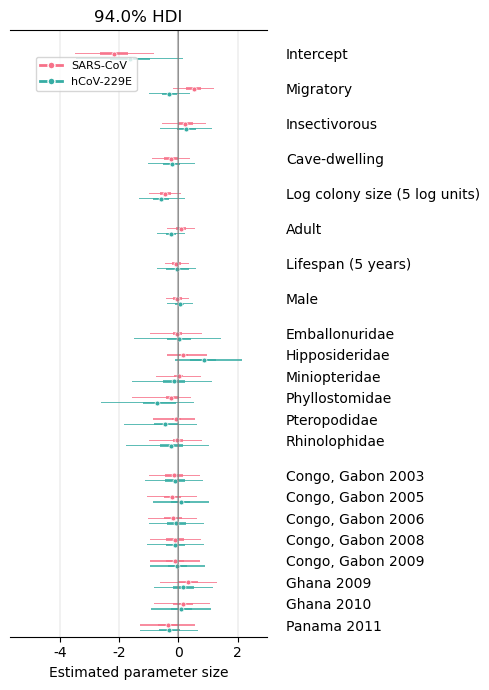

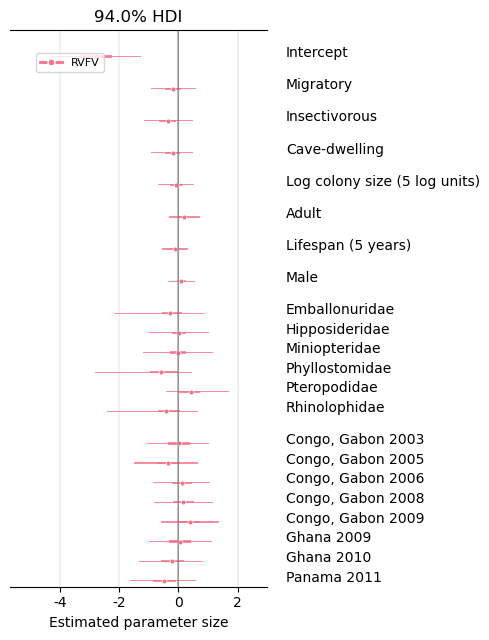

In [62]:
# Plots with multiple viruses
iDataLists = []
for virusFamily in virusFamilies:
    virusFamilyList = []
    for virus in virusFamily:
        virusFamilyList.append(resultsB[virus])
    iDataLists.append(virusFamilyList)

    
virusCount = 0
for virusFamily, iDataList in zip(virusFamilies, iDataLists):
    # Removing viruses form plots that showed large Rhats for posterior estimates
    iDataList = [iDataList[i] for i in range(len(virusFamily)) if not virusFamily[i] in ["rsv", "piv1"]]
    virusFamily = [virus for virus in virusFamily if not virus in ["rsv", "piv1"]]
    if not virusFamily: continue
    if "mumps" in virusFamily:
        markersize=2.5
        linewidth50=0.07
        linewidth94=0.04
        yDistance=0.15
    else:
        markersize=3.5
        linewidth50=0.09
        linewidth94=0.05
        yDistance=0.2

    if len(virusFamily) == 4:
        figsize = (5, 9)
        legendLoc=(0.1, 0.8)
    elif len(virusFamily) == 3:
        figsize=(5, 8)
        legendLoc=(0.1, 0.85)
    elif len(virusFamily) == 2:
        figsize = (5, 7)
        legendLoc=(0.1, 0.9)
    elif len(virusFamily) == 1:
        figsize = (5, 6.5)
        legendLoc=(0.1, 0.925)
        
    labels = [virusesLabels[virus] for virus in virusFamily]
    ax = forestPlotMultipleModels(iDataList, varNames=var_names,
                                  legendLabels=labels, 
                                  yTickLabels=plot_labels[::-1], xlim=(-5.7, 3),
                                  markersize=markersize,
                                  linewidth50=linewidth50,
                                  linewidth94=linewidth94,
                                  yDistance=yDistance,
                                  figsize=figsize, legendLoc=legendLoc)
    ax.vlines(0, ymin=-20, ymax=30, color="gray", alpha=0.5)
    virusCount += len(virusFamily)
    plt.savefig(forestPlotDir / f"{'-'.join(virus for virus in virusFamily)}.png", dpi=600, bbox_inches="tight")

### Posterior predictive check

#### Per virus

In [ ]:
_, ax = plt.subplots(4, 2, figsize=(10, 20))
ax = ax.flatten()

for a, virus in zip(ax, tropicalViruses):
    pm.sample_posterior_predictive(trace=resultsB[virus], model=multilevelModels[virus], 
                                   extend_inferencedata=True)
    az.plot_ppc(resultsB[virus], ax=a)
    a.set_title(virus)
plt.tight_layout()

In [65]:
_, ax = plt.subplots(4, 2, figsize=(10, 20))
ax = ax.flatten()

for a, virus in zip(ax, tropicalViruses):
    dfMultilevelBVirus = dfMultilevelB.dropna(subset=[virus])
    idxSortedColonysize = np.argsort(dfMultilevelBVirus.logColonysizeMean).values
    sns.scatterplot(x=randJitter(dfMultilevelBVirus.logColonysizeMean.iloc[idxSortedColonysize], std=0.02), y=randJitter(dfMultilevelBVirus[virus].iloc[idxSortedColonysize]),
                    alpha=0.15, ax=a)
    pbars = az.extract(resultsB[virus].posterior.p_bar).mean(dim="sample").p_bar.values.flatten()[idxSortedColonysize]
    sns.scatterplot(x=randJitter(dfMultilevelBVirus.logColonysizeMean.iloc[idxSortedColonysize]), y=randJitter(pbars), ax=a, alpha=0.15)
    a.set_title(virus)
plt.tight_layout()

#### Per virus and species

In [ ]:
seroPrevalenceSpecies = defaultdict(list)
for species in dfMultilevelB.species.unique():
    for virus in tropicalViruses:
        dfCurr = dfMultilevelB.dropna(subset=featuresMultilevelB + [virus])
        maskSpecies = dfCurr.species == species
        pbar = az.extract(resultsB[virus].posterior.p_bar).mean(dim="sample").p_bar.values.flatten()
        pbarSpecies = pbar[maskSpecies]
        seroPrevalenceSpecies[species].append(pbarSpecies.mean())

In [ ]:
_, ax = plt.subplots(7, 2, figsize=(20, 60), sharey=True)
ax = ax.flatten()

for a, species in zip(ax, dfMultilevelB.species.unique()):
    dfCurr = dfMultilevelB[dfMultilevelB.species == species].dropna(subset=featuresMultilevelB + [virus])
    seroPrevalenceObs = [dfCurr[virus].mean() for virus in tropicalViruses]
    dfCurr2 = pd.DataFrame({"seroPrev": seroPrevalenceSpecies[species] + seroPrevalenceObs,
                            "virus": list(tropicalViruses) * 2,
                            "observed": ["no"] * len(seroPrevalenceSpecies[species]) + ["yes"] * len(seroPrevalenceObs)})
    sns.barplot(data=dfCurr2, x="virus", y="seroPrev", hue="observed", ax=a)
    a.set_title(species)
    
plt.tight_layout()

## Model comparison

In [1]:
compareResults = {}

for virus in tropicalViruses:
    with simpleModels[virus] as m:
        pm.compute_log_likelihood(simpleResults[virus])
    with multilevelModelsB[virus] as m:
        pm.compute_log_likelihood(multilevelResultsB[virus])
    compareDict = {"modelSimple": simpleResults[virus],
                   "modelMultilevel": multilevelResultsB[virus]}
    compareResults[virus] = az.compare(compare_dict=compareDict, ic="loo")

In [49]:
compareResults

{'denv2':                  rank    elpd_loo      p_loo  elpd_diff  weight         se  \
 modelMultilevel     0 -462.098408  17.134144   0.000000     1.0  18.700453   
 modelSimple         1 -471.824806  11.541539   9.726398     0.0  18.631244   
 
                       dse  warning scale  
 modelMultilevel  0.000000    False   log  
 modelSimple      3.313888    False   log  ,
 'yfv':                  rank    elpd_loo      p_loo  elpd_diff        weight  \
 modelMultilevel     0 -475.684339  16.995343   0.000000  1.000000e+00   
 modelSimple         1 -485.635224  11.278968   9.950885  3.730349e-14   
 
                         se       dse  warning scale  
 modelMultilevel  18.482190  0.000000    False   log  
 modelSimple      18.475226  3.255605    False   log  ,
 'wnv':                  rank    elpd_loo      p_loo  elpd_diff        weight  \
 modelMultilevel     0 -358.038613  14.181645   0.000000  1.000000e+00   
 modelSimple         1 -361.909265   9.267931   3.870652  1.820766e